# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [43]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

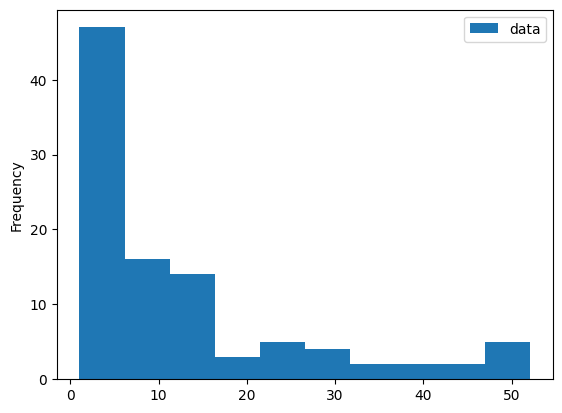

In [44]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

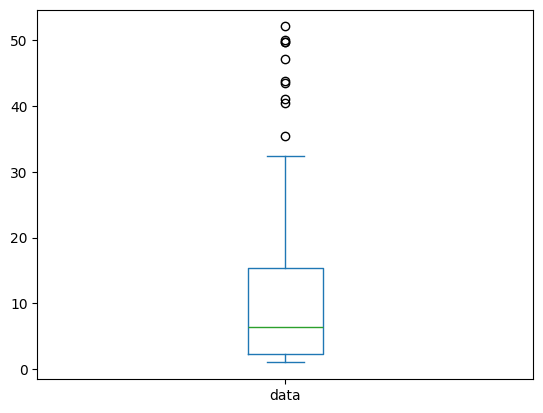

In [45]:
df.plot.box()

**Histogram**

**Pros**
* We can clearly that the shape of distribution is skewed to the right
* We can see the frequency of data points

**Cons**
* It does not show the statistics summary, like quantiles, or medians
* Harder to tell what the potential outliers are
* Visually, if we are looking to answer the question "How much do the more expensive drugs tend to cost relative to the others", it's hard to tell as we don't know what the x-axis represents

**Boxplot**

**Pros**
* It tells us useful information regarding the statistic summary, such as the quantiles, min/max values, median, potential outliers

**Cons**
* Boxplots are usually less intuitive to comprehend for non-mathetical audiences
* Harder to depict the distribution shape

I would choose the boxplot over the histogram since the boxplot contains statistical summary that is useful in answering the administrator's question. We can use the quantiles to show the spread of cost for expensive drugs. The outliers also shows how extreme the costs are in comparision to the cheaper drugs.

To format the graphs better, I would add axis label and title. I would also change the outliers or important values to a more vibrant color so that it stands out.

# 3. Homework - working on your datasets

In [46]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import math
import kagglehub
import os
import seaborn as sns

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot). ✅

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column. ✅

- Find means, medians, and modes. ✅

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

### *Reading in the Dataset:*

In [47]:
# Download latest version
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")

files = os.listdir(path)
df_file = files[0]

df = pd.read_csv(os.path.join(path, df_file))
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### *Means, Medians, Modes, Mins, Maxes*

In [48]:
df_means = df.mean(numeric_only=True)
df_medians = df.median(numeric_only=True)
df_modes = df.mode().iloc[0]
df_max = df.max(numeric_only=True)
df_min = df.min(numeric_only=True)

df_mmm_summary = pd.DataFrame([df_means, df_medians, df_modes, df_min, df_max], index=["mean", "median", "mode", "min", "max"])

df_mmm_summary.T

,mean,median,mode,min,max
Diabetes_012,0.296921,0.0,0.0,0.0,2.0
HighBP,0.429001,0.0,0.0,0.0,1.0
HighChol,0.424121,0.0,0.0,0.0,1.0
CholCheck,0.962670,1.0,1.0,0.0,1.0
BMI,28.382364,27.0,27.0,12.0,98.0
Smoker,0.443169,0.0,0.0,0.0,1.0
Stroke,0.040571,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,0.094186,0.0,0.0,0.0,1.0
PhysActivity,0.756544,1.0,1.0,0.0,1.0
Fruits,0.634256,1.0,1.0,0.0,1.0


### *Bar Plot for Categorical Variables*

In [49]:
# Visually looking at the Appendix, there are 3 variables that are considered numerical:
# (BMI, Mental Health, and Physical Health)
# The rest of the variables are categorical with numerical values representing ordinal categories

# We can look at the number of unique values for each column to determine which are categorical or not
# I googled "how do I check unique values in a dataframe"
print(df.nunique())

categorical_variables = df.columns[df.nunique() <= 13].to_list()
numerical_variables = df.columns[df.nunique() > 13].to_list()

print("Categorical Variables:", categorical_variables)
print("Numerical Variables:", numerical_variables)

Diabetes_012             3
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     84
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
dtype: int64
Categorical Variables: ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
Numerical Variables: ['BMI', 'MentHlth', 'PhysHlth']


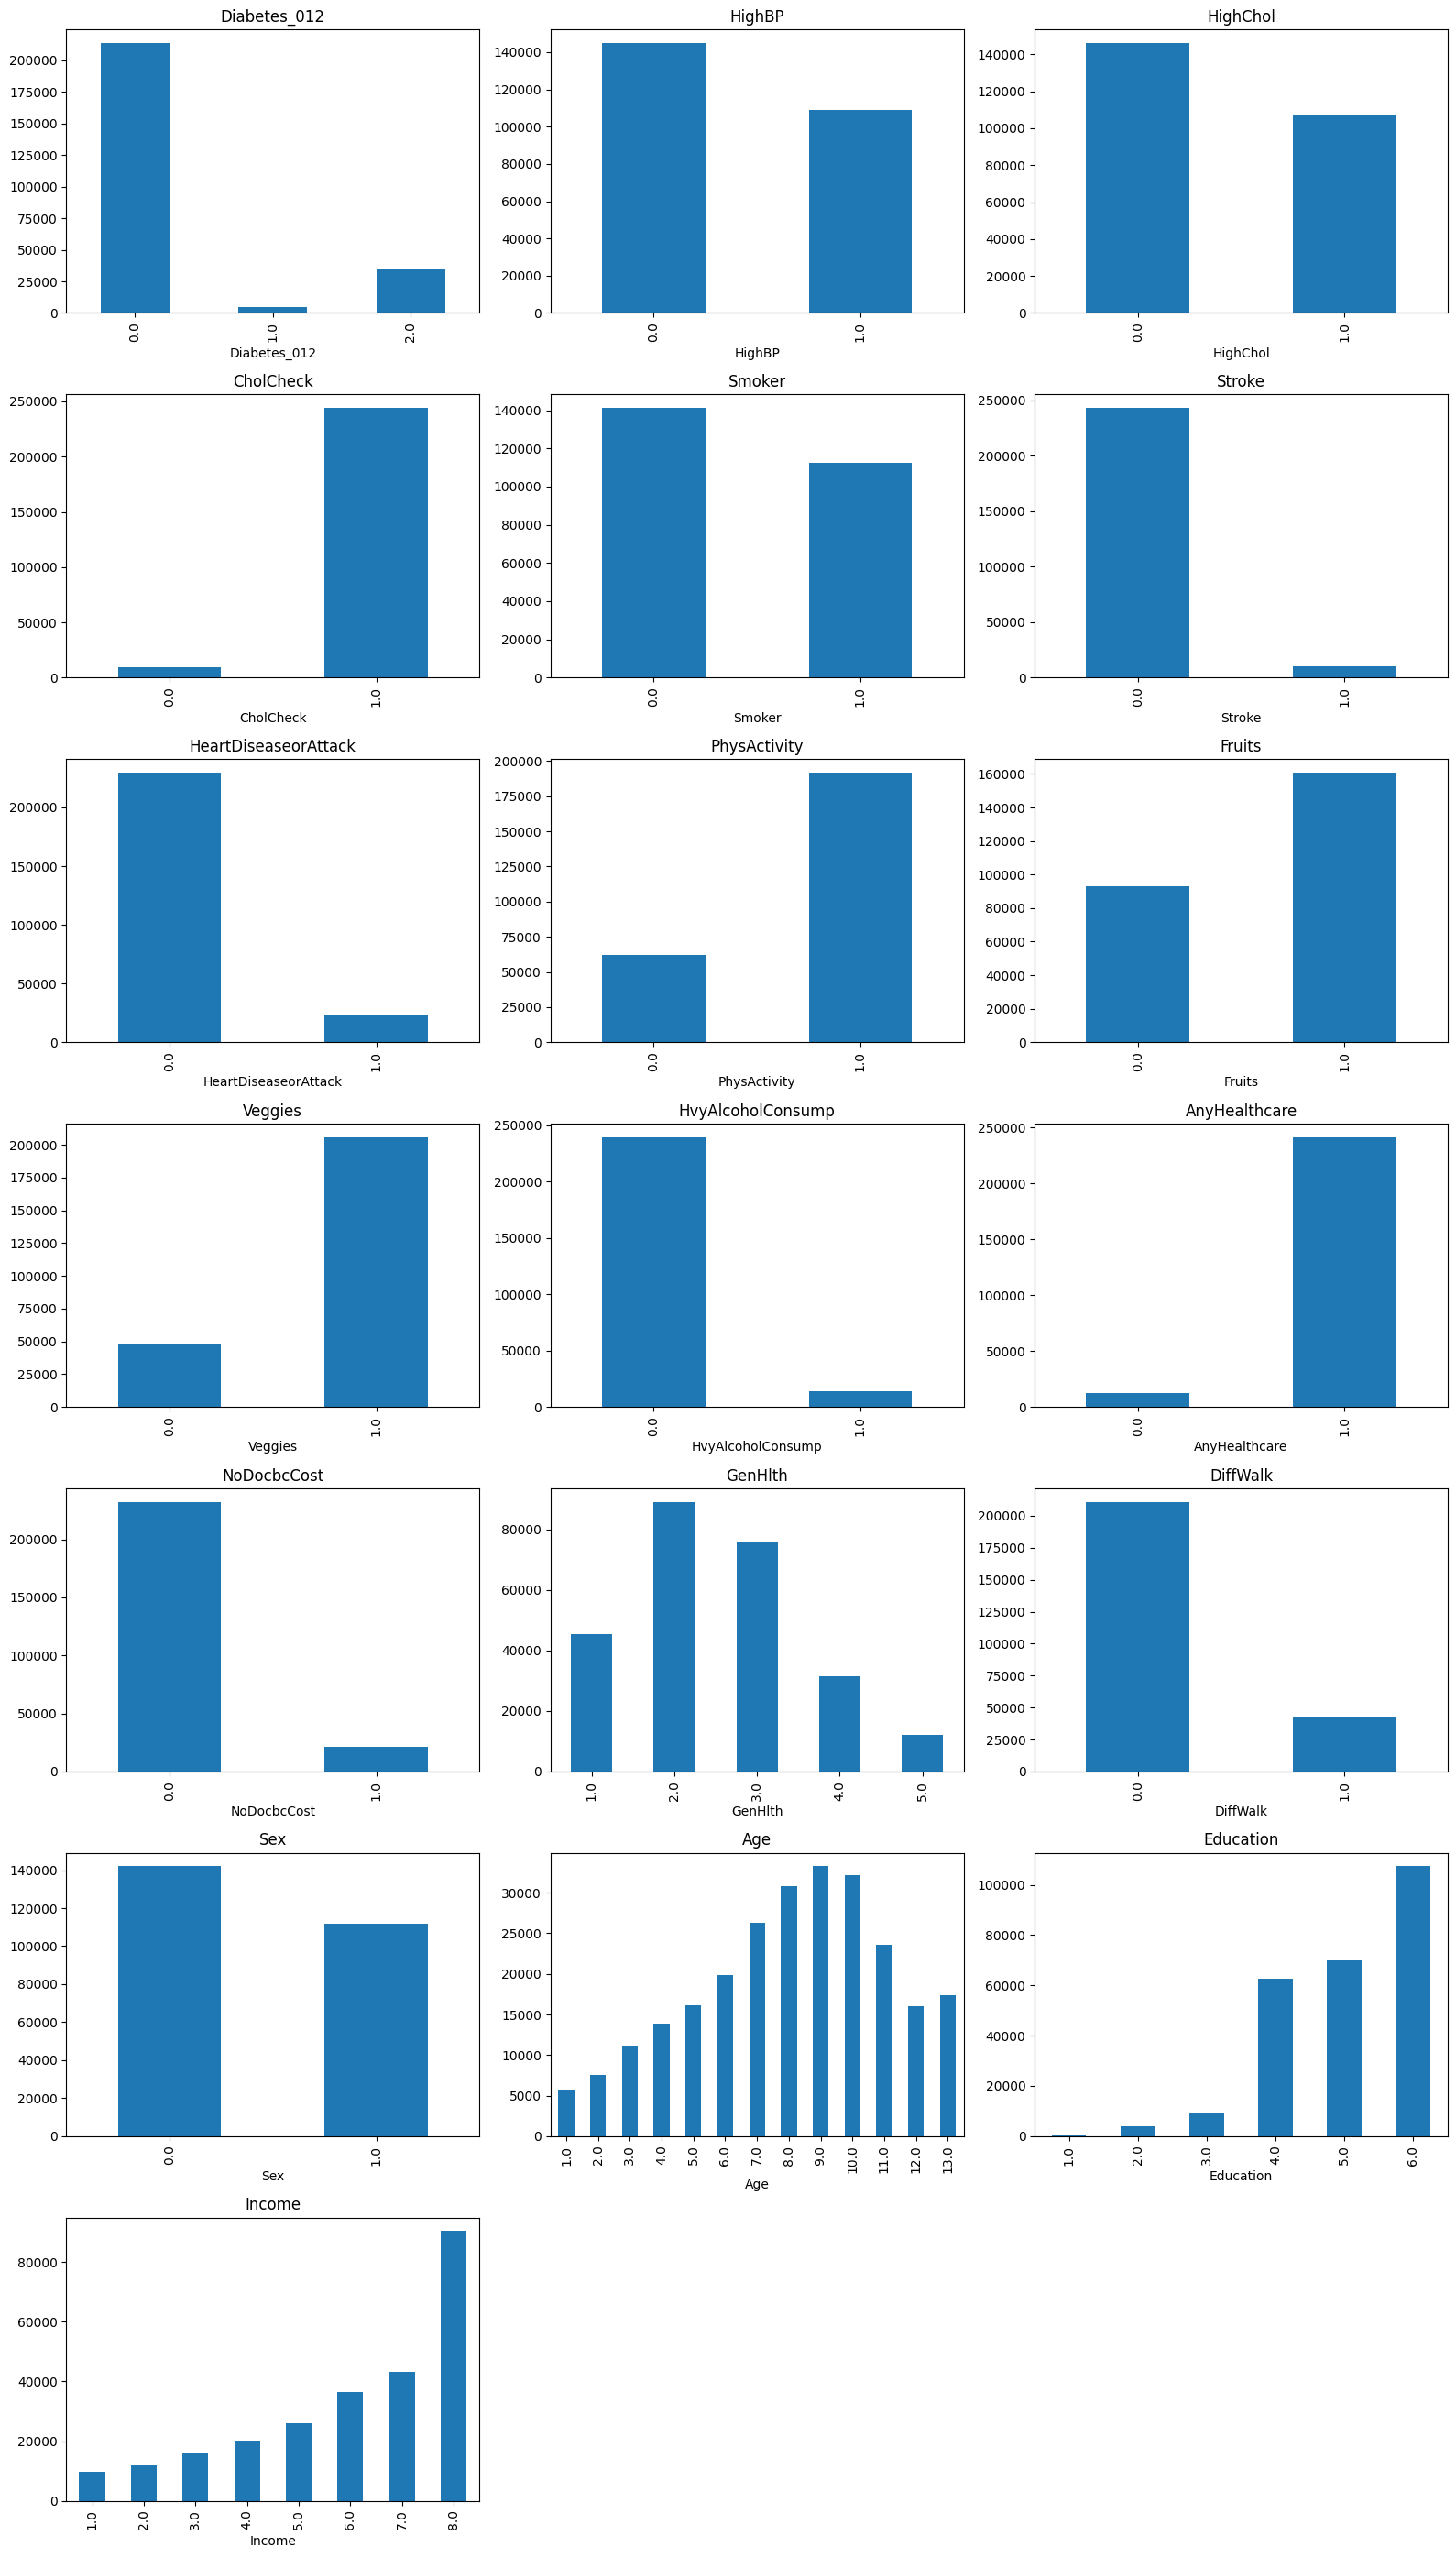

In [50]:
# I asked CHATGPT: How do I graph subplots for columns in a dataframe?
# I got the sample code it gave me and adjusted it to fit my dataset to display frequency

n = len(categorical_variables)
cols = 3  # number of subplot columns
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()  # makes indexing easier

for i, col in enumerate(categorical_variables):
    df[col].value_counts().sort_index().plot(
        kind='bar',
        ax=axes[i]
    )
    axes[i].set_title(col)

# Remove any unused empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### *Histogram For Each Column (Numerical Variables only)*
Plotting Histograms for Categorical Variables is redundant as the results are the same as the bar plot we created above. Therefore, here are histograms for the numerical values only


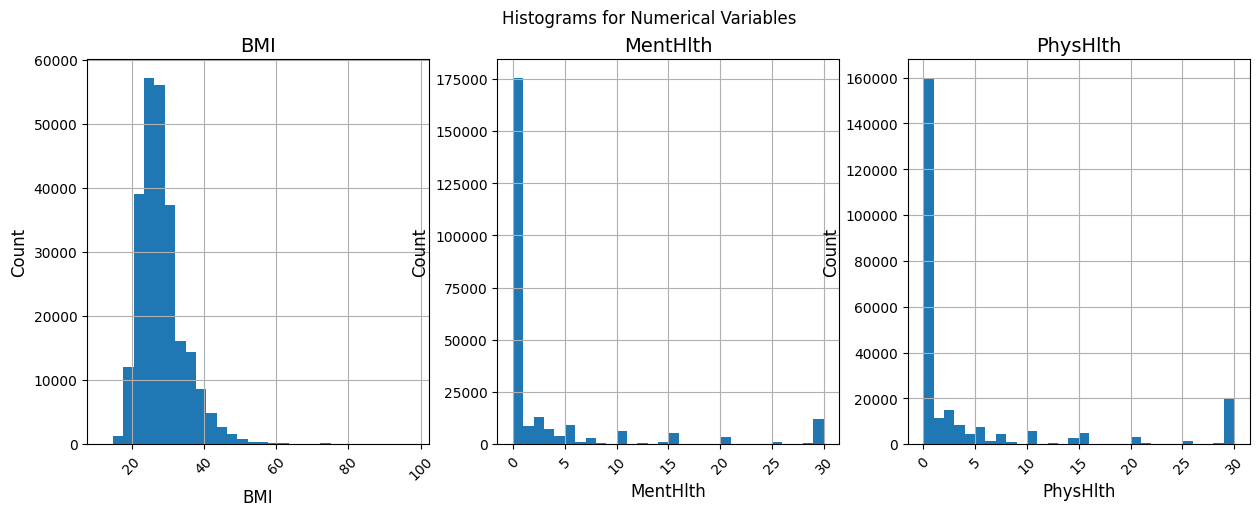

In [51]:
nums_cols = len(numerical_variables)
nums_rows = rows = math.ceil(nums_cols / cols)

fig, axes = plt.subplots(nums_rows, nums_cols, figsize=(15, rows * 5))
axes = axes.flatten()

for i, col in enumerate(numerical_variables):
    df[col].hist(bins=30, ax=axes[i])
    axes[i].set_title(f"{col}", fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel("Count", fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Histograms for Numerical Variables")
plt.show()

### *Violin Plot For Each Numerical Variables*

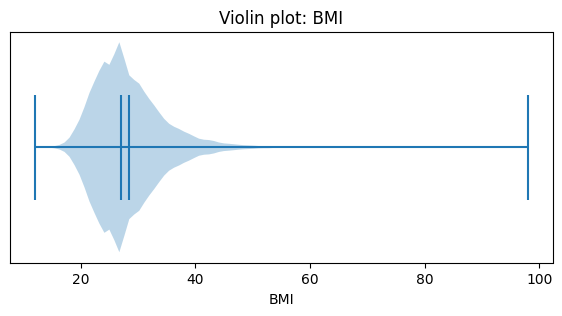

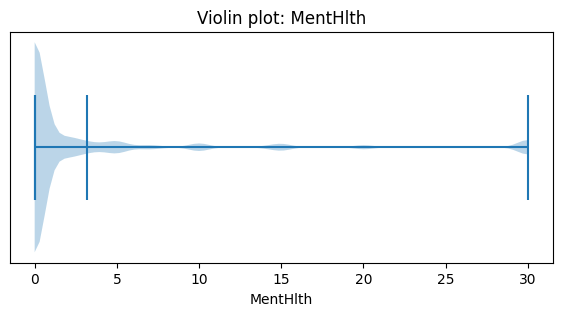

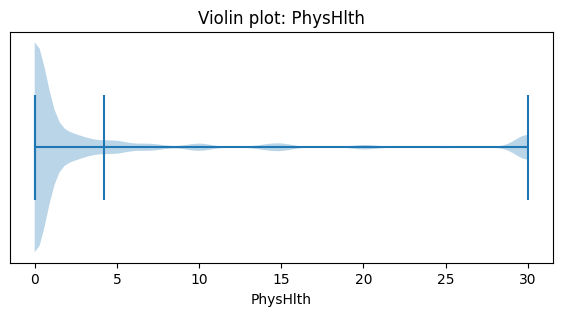

In [52]:
for col in numerical_variables:
    s = df[col].dropna()
    fig, ax = plt.subplots(figsize=(7,3))
    ax.violinplot(s.values, vert=False, showmeans=True, showmedians=True)
    ax.set_title(f"Violin plot: {col}")
    ax.set_xlabel(col)
    ax.set_yticks([])
    plt.show()

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!
*The dataset is usable as there are no missing values and every categorical variable is consistent with its ordinal categories*

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?
*The numerical variables (BMI, MentHlth/PhysHlth) are right-skewed*

- Are there any outliers present?  (Data points that are far from the others.)
*MentHlth/PhysHlth have a lot of 30 days values*

# Appendix

| Variable             | Description                                                                                                                                                                                                                                                                                                                                               |
|----------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Diabetes_012             | 0 = no diabetes<br>1 = prediabetes<br>2 = diabetes                                                                                                                                                                                                                                                                                                        |
| HighBP               | 0 = no high BP<br>1 = high BP                                                                                                                                                                                                                                                                                                                             |
| HighChol             | 0 = no high cholesterol<br>1 = high cholesterol                                                                                                                                                                                                                                                                                                           |
| CholCheck            | 0 = no cholesterol check in 5 years<br>1 = yes cholesterol check in 5 years                                                                                                                                                                                                                                                                               |
| BMI                  | Body Mass Index                                                                                                                                                                                                                                                                                                                                           |
| Smoker               | Have you smoked at least 100 cigarettes in your entire life?<br>[Note: 5 packs = 100 cigarettes]<br>0 = no <br>1 = yes                                                                                                                                                                                                                                    |
| Stroke               | (Ever told) you had a stroke. <br>0 = no <br>1 = yes                                                                                                                                                                                                                                                                                                      |
| HeartDiseaseorAttack | Coronary heart disease (CHD) or myocardial infarction (MI)<br>0 = no<br>1 = yes                                                                                                                                                                                                                                                                           |
| PhysActivity         | Physical activity in past 30 days - not including job<br>0 = no<br>1 = yes                                                                                                                                                                                                                                                                                |
| Fruits               | Consume Fruit 1 or more times per day<br>0 = no<br>1 = yes                                                                                                                                                                                                                                                                                                |
| Veggies              | Consume Vegetables 1 or more times per day<br>0 = no<br>1 = yes                                                                                                                                                                                                                                                                                           |
| HvyAlcoholConsump    | Heavy drinkers (adult men having more than 14 drinks per week<br>and adult women having more than 7 drinks per week)<br>0 = no<br>1 = yes                                                                                                                                                                                                                 |
| AnyHealthCare        | Have any kind of health care coverage, including health insurance<br>insurance, prepaid plans such as HMO, etc.<br>0 = no<br>1 = yes                                                                                                                                                                                                                      |
| NoDocbcCost          | Was there a time in the past 12 months when you needed to see <br>a doctor, but could not because of cost?<br>0 = no<br>1 = yes                                                                                                                                                                                                                           |
| GenHlth              | Would you say that in general your health is: scale 1-5<br>1 = excellent<br>2 = very good<br>3 = good<br>4 = fair<br>5 = poor                                                                                                                                                                                                                             |
| MentHlth             | Now thinking about your mental health, which includes<br>stress, depression, and problems with emotions, for <br>how many days during the past 30 days was your mental <br>health not good? scale 1-30 days                                                                                                                                               |
| PhysHlth             | Now thinking about your physical health, which includes<br>physical illness and injury, for how many days during<br>the past 30 days was your physical health not good? <br>scale 1-30 days                                                                                                                                                               |
| DiffWalk             | Do you have serious difficulty walking or climbing stairs? <br>0 = no <br>1 = yes                                                                                                                                                                                                                                                                         |
| Sex                  | 0 = female<br>1 = male                                                                                                                                                                                                                                                                                                                                    |
| Age                  | 13-level age category (_AGEG5YR see codebook)<br>1 = 18-24<br>9 = 60-64<br>13 = 80 or older                                                                                                                                                                                                                                                               |
| Education            | Education level (EDUCA see codebook) scale 1-6<br>1 = Never attended school or only kindergarten<br>2 = Grades 1 through 8 (Elementary)<br>3 = Grades 9 through 11 (Some high school)<br>4 = Grade 12 or GED (High school graduate)<br>5 = College 1 year to 3 years (Some college or technical school)<br>6 = College 4 years or more (College graduate) |
| Income               | Income scale (INCOME2 see codebook) scale 1-8<br>1 = less than $10,000<br>5 = less than $35,000<br>8 = $75,000 or more                                                                                                                                                                                                                                    |

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

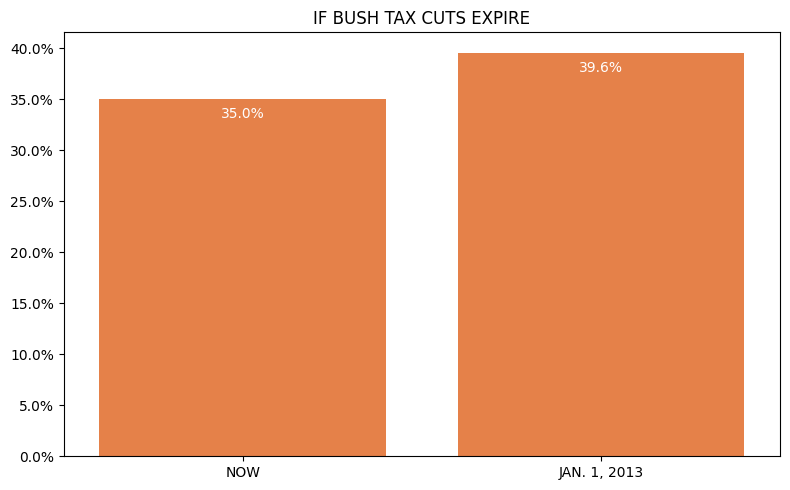

In [53]:
import matplotlib.ticker as mtick

dates = ["NOW", "JAN. 1, 2013"]
values = [0.35, 0.396]

plt.figure(figsize=(8,5))
ax = sns.barplot(x=dates, y=values, color="#ff7a2f", orient='v')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))  # format y ticks as percent

# Annotate each bar above with percent text
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{100*height:.1f}%',
                (p.get_x() + p.get_width() / 2, height * 0.98),
                ha='center',
                va='top',
                color='white',
                fontsize=10)
plt.title('IF BUSH TAX CUTS EXPIRE')
plt.tight_layout()
plt.show()